# Color channels

```TEXT
Color channel is hidden, grayscale layer that tells computer screen exactly how much of specific primary color to mix into each pixel. by stacking these seperate colors directly on top of each other, our screen blends light together to create illusion of millions vibrant colors.


Color spaces are  specific organisations of colors that allow us to consistently represent and reproduce colors. A color model, on the other hand, is an abstract method of numerically representing colors in the color space. As a whole, a color space defines both the color model and the abstract mapping function used to define actual colors.

**Quick Reference: How OpenCV & Matplotlib Handle Image Channels**

 1. *The Core Secret*
* **No color tags:** The split channels (`b`, `g`, `r`) are **not** colored images. They are just 2D grids (spreadsheets) of raw numbers (`0` to `255`) representing light intensity.
* **Pixel Autonomy:** Every pixel has its own independent value depending on what the camera captured.


2. *What Happens During `cv.imshow(g)` or `plt.imshow(g)`?*

Because we pass only **one** channel, the computer can't mix colors. It duplicates that specific pixel's value across all three monitor color guns (R, G, and B):

* **High Green Value (e.g., 220 on a leaf):** Duplicated to `(220, 220, 220)` $\rightarrow$ Displays as **Bright White/Gray**
* **Low Green Value (e.g., 15 on a red apple):** Duplicated to `(15, 15, 15)` $\rightarrow$ Displays as **Dark Black/Gray**

>  **Rule of Thumb:** In a single channel view, **White = "Yes, a lot of this color exists here"** and **Black = "No, this color does not exist here"**.


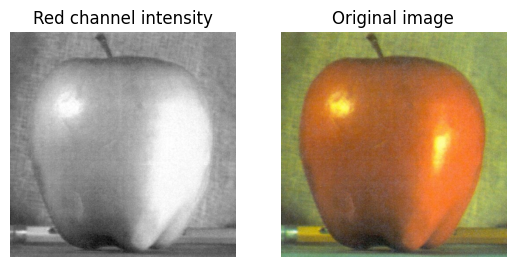

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img=cv.imread("../image/apple.jpg")

b,g,r=cv.split(img)

plt.subplot(1,2,1)
plt.title("Red channel intensity")
plt.imshow(r,cmap="gray")
plt.axis("off")


# since we are using matlab
merged=cv.merge([r,g,b])
plt.subplot(1,2,2)
plt.title("Original image")
plt.imshow(merged)
plt.axis("off")
plt.show()


In [4]:
print(img.shape)
print(r.shape)

(512, 512, 3)
(512, 512)


**"Visualizing RGB Color Channels Using Image and Blank Masks"**

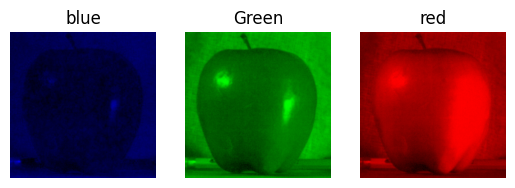

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img=cv.imread("../image/apple.jpg")
blank=np.zeros(img.shape[:2],dtype="uint8")

b,g,r=cv.split(img)

# for matplotlib in RGB format
blue_rgb  = cv.merge([blank, blank, b])  # RGB
green_rgb = cv.merge([blank, g, blank])  # RGB
red_rgb   = cv.merge([r, blank, blank])  # RGB


# but in opencv
# blue=cv.merge([b,blank,blank])
# green=cv.merge([blank,g,blank]) 
# red=cv.merge([blank,blank,r])


plt.subplot(1,3,1)
plt.title("blue")
plt.imshow(blue_rgb)
plt.axis("off")


# since we are using matplotlib
merged=cv.merge([r,g,b])
plt.subplot(1,3,2)
plt.title("Green")
plt.imshow(green_rgb)
plt.axis("off")

plt.subplot(1,3,3)
plt.title("red")
plt.imshow(red_rgb)
plt.axis("off")
plt.show()


```TEXT
The key rule is:

OpenCV: BGR
Matplotlib: RGB

Whenever you pass a 3-channel image from OpenCV to Matplotlib, either convert with cv.cvtColor(..., cv.COLOR_BGR2RGB) or arrange the channels in RGB order yourself.